
# 1. Use 5 tabular datasets and realize the different types of gradient descent from scratch.
# 2. Also explore the contour plots for the same from scratch in 3D and 2D plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

df1 = pd.read_csv('/content/student_scores.csv')
df2 = pd.read_csv('/content/student_performance.csv')
df3 = pd.read_csv('/content/house_price_regression_dataset.csv')
df4 = pd.read_csv('/content/boston_housing.csv')
df5 = pd.read_csv('/content/concrete_data.csv')

In [2]:
print(df1.head())
print(df2.head())
print(df3.head())
print(df4.head())
print(df5.head())

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30
   student_id            name  gender  age class  teacher_id   subject  \
0           1   Carson Rivera  Female   14   9th         105      Math   
1           2  Ashley Walters    Male   15  10th         107  Computer   
2           3  Linda Robinson    Male   15  10th         103   English   
3           4   Brandon James  Female   17  11th         117  Computer   
4           5     Helen Grant  Female   16  10th         112   Science   

   test1_score  test2_score  final_exam_score final_grade_letter  \
0         23.5         40.5              50.5                  F   
1         77.7         80.6              82.3                  B   
2         75.0         73.4              64.5                  C   
3         46.7         53.1              51.2                  F   
4         38.0         57.3              47.6                  F   

   attendance_percentage  study_hours_per_we

## Gradient Descent Functions

In [3]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]
def cost(X, y, w):
    pred = X @ w
    return np.mean((pred - y) ** 2) / 2
def batch_gd(X, y, lr=0.01, epochs=500):
    w = np.zeros(X.shape[1])
    history = []
    for i in range(epochs):
        pred = X @ w
        grad = (X.T @ (pred - y)) / len(y)
        w = w - lr * grad
        history.append(cost(X, y, w))
    return w, history

def stochastic_gd(X, y, lr=0.01, epochs=100):
    w = np.zeros(X.shape[1])
    history = []
    for i in range(epochs):
        order = np.random.permutation(len(y))
        for j in order:
            pred = X[j] @ w
            grad = X[j] * (pred - y[j])
            w = w - lr * grad
        history.append(cost(X, y, w))
    return w, history

def mini_batch_gd(X, y, lr=0.01, epochs=100, batch_size=32):
    w = np.zeros(X.shape[1])
    history = []
    for i in range(epochs):
        order = np.random.permutation(len(y))
        X1 = X[order]
        y1 = y[order]
        for j in range(0, len(y), batch_size):
            xb = X1[j:j + batch_size]
            yb = y1[j:j + batch_size]
            pred = xb @ w
            grad = (xb.T @ (pred - yb)) / len(yb)
            w = w - lr * grad
        history.append(cost(X, y, w))

    return w, history

In [4]:
#setup
def prepare_data(df, target):
    data = df.select_dtypes(include=np.number).dropna()
    X = data.drop(columns=[target]).values
    y = data[target].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = add_bias(X_train)
    X_test = add_bias(X_test)

    return X_train, X_test, y_train, y_test

In [5]:
print(df1.columns)

Index(['Hours', 'Scores'], dtype='object')


In [6]:
X_train, X_test, y_train, y_test = prepare_data(df1, 'Scores')
w1, h1 = batch_gd(X_train, y_train)
w2, h2 = stochastic_gd(X_train, y_train)
w3, h3 = mini_batch_gd(X_train, y_train)

print("Batch MSE:", mean_squared_error(y_test, X_test @ w1))
print("Stochastic MSE:", mean_squared_error(y_test, X_test @ w2))
print("Mini Batch MSE:", mean_squared_error(y_test, X_test @ w3))

Batch MSE: 19.880383381039373
Stochastic MSE: 18.902546064225795
Mini Batch MSE: 513.8915803556899


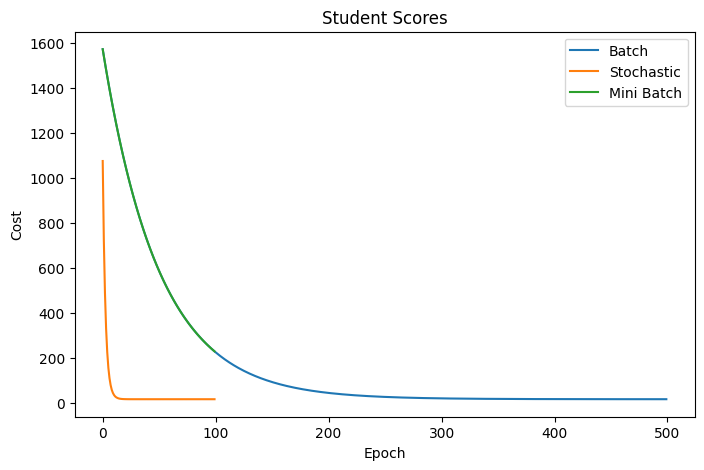

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(h1, label='Batch')
plt.plot(h2, label='Stochastic')
plt.plot(h3, label='Mini Batch')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Student Scores')
plt.legend()
plt.show()

In [8]:
print(df2.columns)

Index(['student_id', 'name', 'gender', 'age', 'class', 'teacher_id', 'subject',
       'test1_score', 'test2_score', 'final_exam_score', 'final_grade_letter',
       'attendance_percentage', 'study_hours_per_week',
       'assignments_submitted', 'pass_fail'],
      dtype='object')


In [9]:
target2 = df2.select_dtypes(include=np.number).columns[-1]
X_train, X_test, y_train, y_test = prepare_data(df2, target2)

w1, h1 = batch_gd(X_train, y_train)
w2, h2 = stochastic_gd(X_train, y_train)
w3, h3 = mini_batch_gd(X_train, y_train)

print("Target:", target2)
print("Batch MSE:", mean_squared_error(y_test, X_test @ w1))
print("Stochastic MSE:", mean_squared_error(y_test, X_test @ w2))
print("Mini Batch MSE:", mean_squared_error(y_test, X_test @ w3))

Target: pass_fail
Batch MSE: 0.08090633225628491
Stochastic MSE: 0.08477918272021726
Mini Batch MSE: 0.07982105235486087


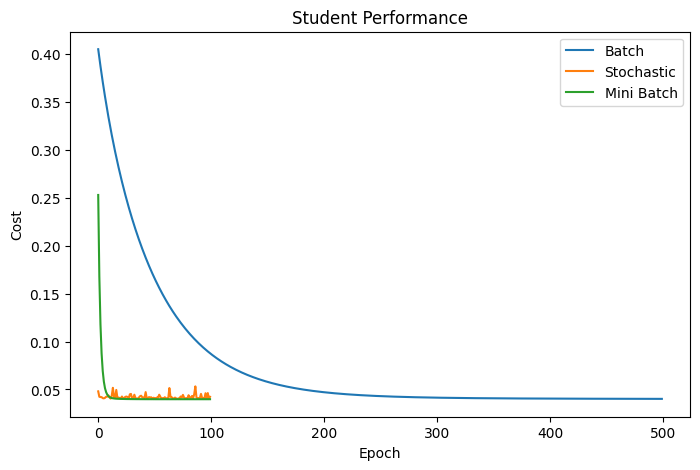

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(h1, label='Batch')
plt.plot(h2, label='Stochastic')
plt.plot(h3, label='Mini Batch')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Student Performance')
plt.legend()
plt.show()

In [11]:
print(df3.columns)

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


In [12]:
target3 = df3.select_dtypes(include=np.number).columns[-1]
X_train, X_test, y_train, y_test = prepare_data(df3, target3)

w1, h1 = batch_gd(X_train, y_train)
w2, h2 = stochastic_gd(X_train, y_train)
w3, h3 = mini_batch_gd(X_train, y_train)

print("Target:", target3)
print("Batch MSE:", mean_squared_error(y_test, X_test @ w1))
print("Stochastic MSE:", mean_squared_error(y_test, X_test @ w2))
print("Mini Batch MSE:", mean_squared_error(y_test, X_test @ w3))

Target: House_Price
Batch MSE: 128264822.10758126
Stochastic MSE: 105894815.60136263
Mini Batch MSE: 101426186.70781375


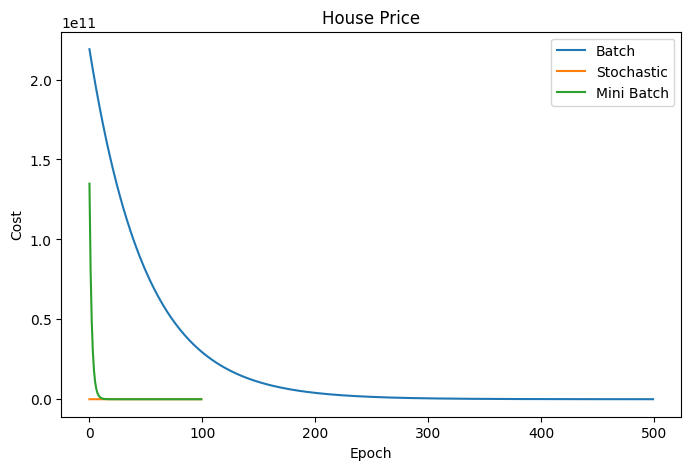

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(h1, label='Batch')
plt.plot(h2, label='Stochastic')
plt.plot(h3, label='Mini Batch')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('House Price')
plt.legend()
plt.show()

In [14]:
print(df4.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


In [15]:
target4 = df4.select_dtypes(include=np.number).columns[-1]
X_train, X_test, y_train, y_test = prepare_data(df4, target4)

w1, h1 = batch_gd(X_train, y_train)
w2, h2 = stochastic_gd(X_train, y_train)
w3, h3 = mini_batch_gd(X_train, y_train)

print("Target:", target4)
print("Batch MSE:", mean_squared_error(y_test, X_test @ w1))
print("Stochastic MSE:", mean_squared_error(y_test, X_test @ w2))
print("Mini Batch MSE:", mean_squared_error(y_test, X_test @ w3))

Target: MEDV
Batch MSE: 26.352453960828004
Stochastic MSE: 24.535122763983118
Mini Batch MSE: 24.960908656951705


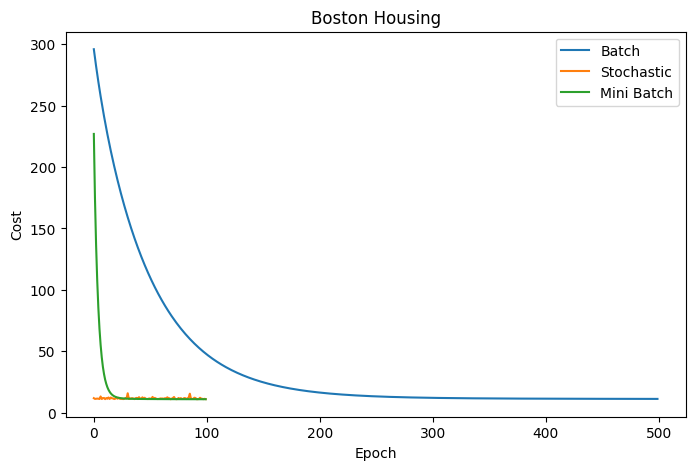

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(h1, label='Batch')
plt.plot(h2, label='Stochastic')
plt.plot(h3, label='Mini Batch')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Boston Housing')
plt.legend()
plt.show()

In [17]:
print(df5.columns)

Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate ', 'age',
       'concrete_compressive_strength'],
      dtype='object')


In [18]:
target5 = df5.select_dtypes(include=np.number).columns[-1]

X_train, X_test, y_train, y_test = prepare_data(df5, target5)

w1, h1 = batch_gd(X_train, y_train)
w2, h2 = stochastic_gd(X_train, y_train)
w3, h3 = mini_batch_gd(X_train, y_train)

print("Target:", target5)
print("Batch MSE:", mean_squared_error(y_test, X_test @ w1))
print("Stochastic MSE:", mean_squared_error(y_test, X_test @ w2))
print("Mini Batch MSE:", mean_squared_error(y_test, X_test @ w3))

Target: concrete_compressive_strength
Batch MSE: 101.01644063919731
Stochastic MSE: 109.16851925797454
Mini Batch MSE: 96.98522743706847


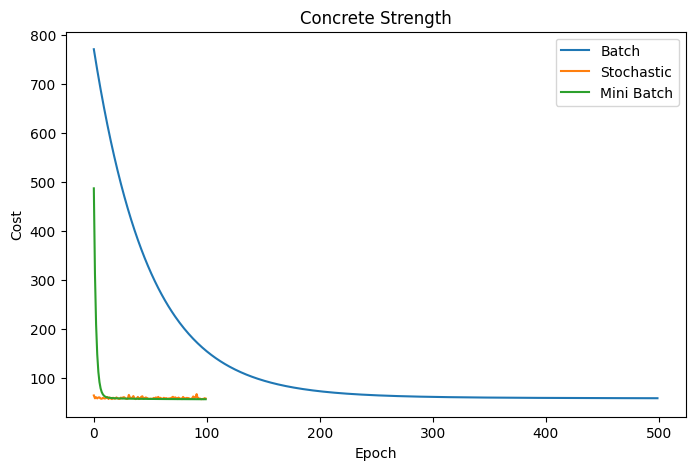

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(h1, label='Batch')
plt.plot(h2, label='Stochastic')
plt.plot(h3, label='Mini Batch')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Concrete Strength')
plt.legend()
plt.show()

## 2D Contour Plot

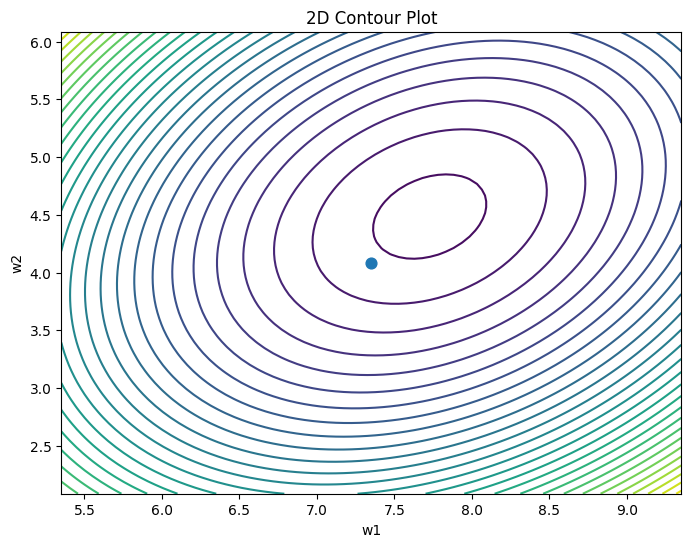

In [20]:
def contour_plot(X, y, w):
    x1 = X[:, 1]
    x2 = X[:, 2]

    a = np.linspace(w[1] - 2, w[1] + 2, 80)
    b = np.linspace(w[2] - 2, w[2] + 2, 80)

    A, B = np.meshgrid(a, b)
    Z = np.zeros(A.shape)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            temp = w.copy()
            temp[1] = A[i, j]
            temp[2] = B[i, j]
            Z[i, j] = cost(X, y, temp)

    plt.figure(figsize=(8, 6))
    plt.contour(A, B, Z, levels=30)
    plt.scatter(w[1], w[2], s=60)
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.title('2D Contour Plot')
    plt.show()

contour_plot(X_train, y_train, w1)

## 3D Surface Plot

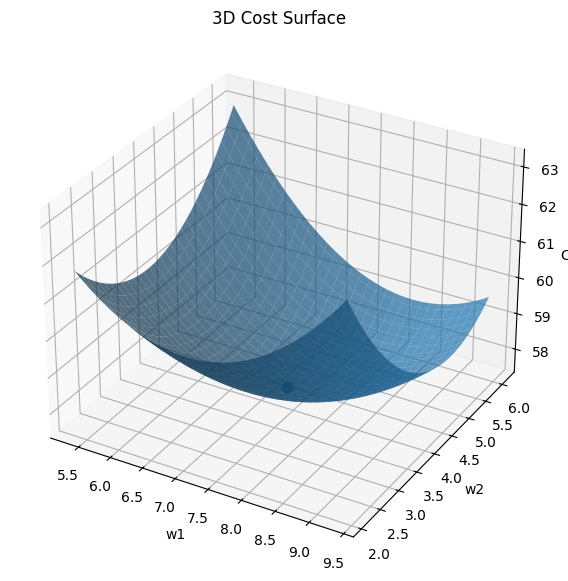

In [21]:
def surface_plot(X, y, w):
    a = np.linspace(w[1] - 2, w[1] + 2, 60)
    b = np.linspace(w[2] - 2, w[2] + 2, 60)

    A, B = np.meshgrid(a, b)
    Z = np.zeros(A.shape)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            temp = w.copy()
            temp[1] = A[i, j]
            temp[2] = B[i, j]
            Z[i, j] = cost(X, y, temp)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A, B, Z, alpha=0.7)
    ax.scatter(w[1], w[2], cost(X, y, w), s=60)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_zlabel('Cost')
    ax.set_title('3D Cost Surface')
    plt.show()

surface_plot(X_train, y_train, w1)

## Gradient Descent Comparison

In [22]:
results = pd.DataFrame({
    'Method': ['Batch', 'Stochastic', 'Mini Batch'],
    'Test MSE': [
        mean_squared_error(y_test, X_test @ w1),
        mean_squared_error(y_test, X_test @ w2),
        mean_squared_error(y_test, X_test @ w3)
    ]
})

results

,Method,Test MSE
0,Batch,101.016441
1,Stochastic,109.168519
2,Mini Batch,96.985227
